In [8]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.pdm.data_loader import load_raw_data, build_base_dataframe
from src.pdm.features import build_feature_matrix

sns.set_theme(style="whitegrid")
raw = load_raw_data("../data/raw/")
base_df = build_base_dataframe(raw)
print("Base dataframe:", base_df.shape)
print(base_df.columns)

Base dataframe: (876100, 8)
Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'model', 'age'],
      dtype='object')


In [2]:
feature_df = build_feature_matrix(
    base_df, raw["errors"], raw["maint"], window_hours=[3, 12, 24]
)
print(f"Feature matrix: {feature_df.shape}")
print(f"\nFeature groups:")
print(f"  Telemetry rolling: {len([c for c in feature_df.columns if any(s in c for s in ['volt','rotate','pressure','vibration']) and '_h' in c])}")
print(f"  Error counts:      {len([c for c in feature_df.columns if 'error' in c and 'count' in c])}")
print(f"  Maintenance:       {len([c for c in feature_df.columns if 'hours_since' in c])}")
print(f"  Machine metadata:  {len([c for c in feature_df.columns if c.startswith('model_') or c == 'age'])}")
feature_df.head()

Feature matrix: (876100, 78)

Feature groups:
  Telemetry rolling: 0
  Error counts:      15
  Maintenance:       4
  Machine metadata:  5


,datetime,machineID,volt,rotate,pressure,vibration,age,volt_mean_3h,volt_std_3h,volt_min_3h,...,error4_count_24h,error5_count_24h,hours_since_comp1,hours_since_comp2,hours_since_comp3,hours_since_comp4,model_model1,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,176.217853,0.000000,176.217853,...,0.0,0.0,456.0,5136.0,3696.0,4056.0,False,False,True,False
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,169.548538,9.431836,162.879223,...,0.0,0.0,457.0,5137.0,3697.0,4057.0,False,False,True,False
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,170.028993,6.721032,162.879223,...,0.0,0.0,458.0,5138.0,3698.0,4058.0,False,False,True,False
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,165.443986,4.807415,162.462833,...,0.0,0.0,459.0,5139.0,3699.0,4059.0,False,False,True,False
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,163.687586,6.773501,157.610021,...,0.0,0.0,460.0,5140.0,3700.0,4060.0,False,False,True,False


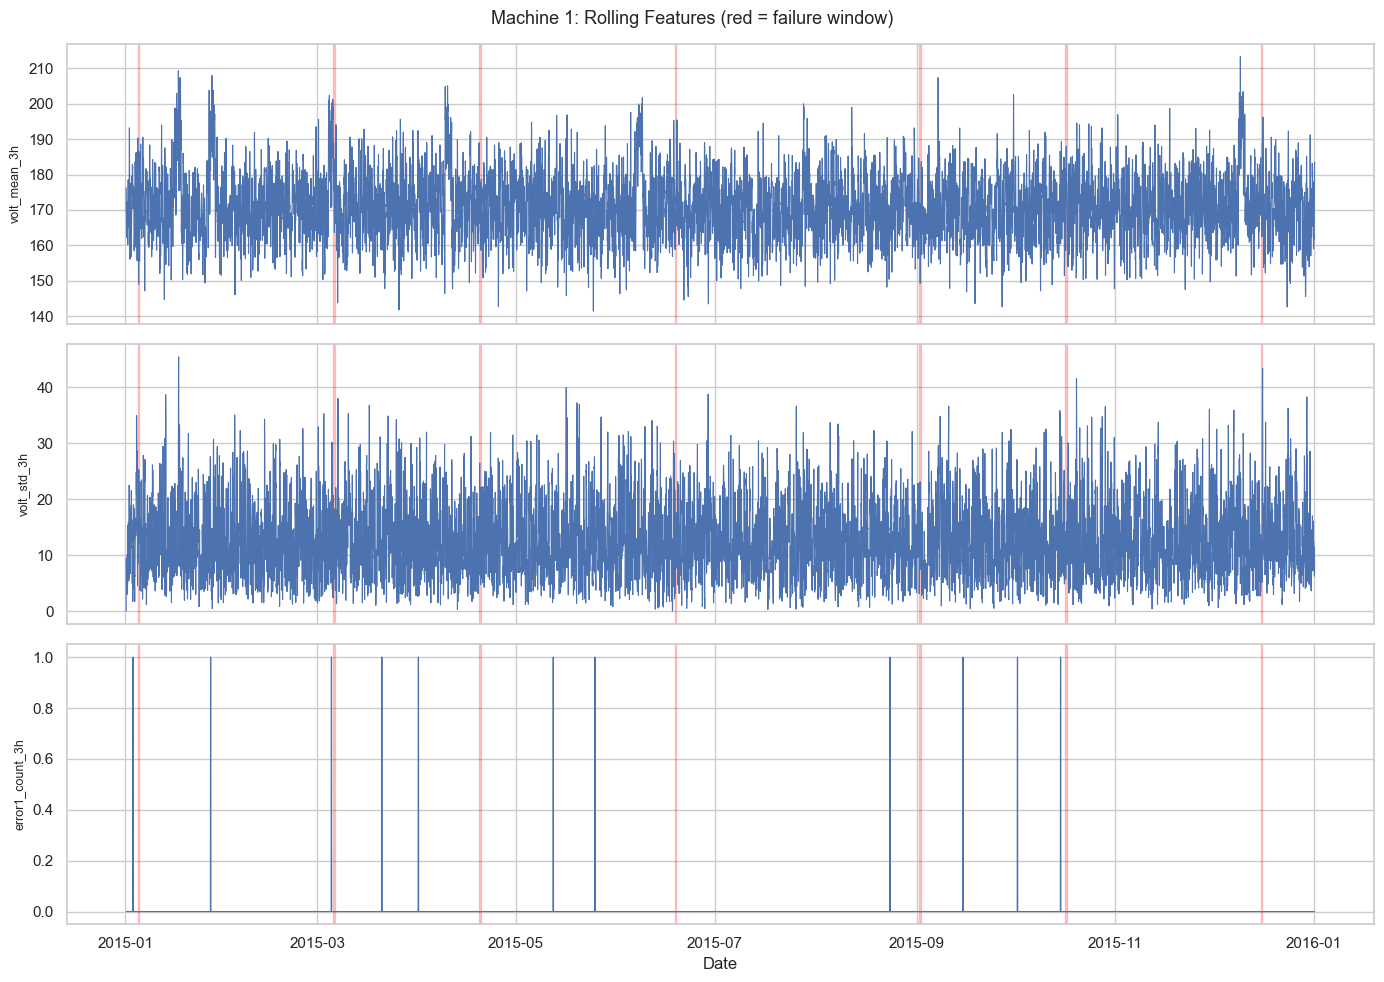

In [4]:
from src.pdm.labels import make_labels

feature_df_sorted = feature_df.sort_values("datetime")
labels = make_labels(feature_df_sorted, raw["failures"], horizon_hours=12)

machine_id = 1
machine_df = feature_df_sorted[feature_df_sorted["machineID"] == machine_id].copy()
machine_failures = raw["failures"][raw["failures"]["machineID"] == machine_id]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
cols = ["volt_mean_3h", "volt_std_3h", "error1_count_3h"]
for ax, col in zip(axes, cols):
    ax.plot(machine_df["datetime"], machine_df[col], lw=0.8)
    for _, row in machine_failures.iterrows():
        ax.axvspan(row["datetime"] - pd.Timedelta(hours=12), row["datetime"], alpha=0.2, color="red")
    ax.set_ylabel(col, fontsize=9)
axes[-1].set_xlabel("Date")
fig.suptitle(f"Machine {machine_id}: Rolling Features (red = failure window)", fontsize=13)
plt.tight_layout()
plt.show()

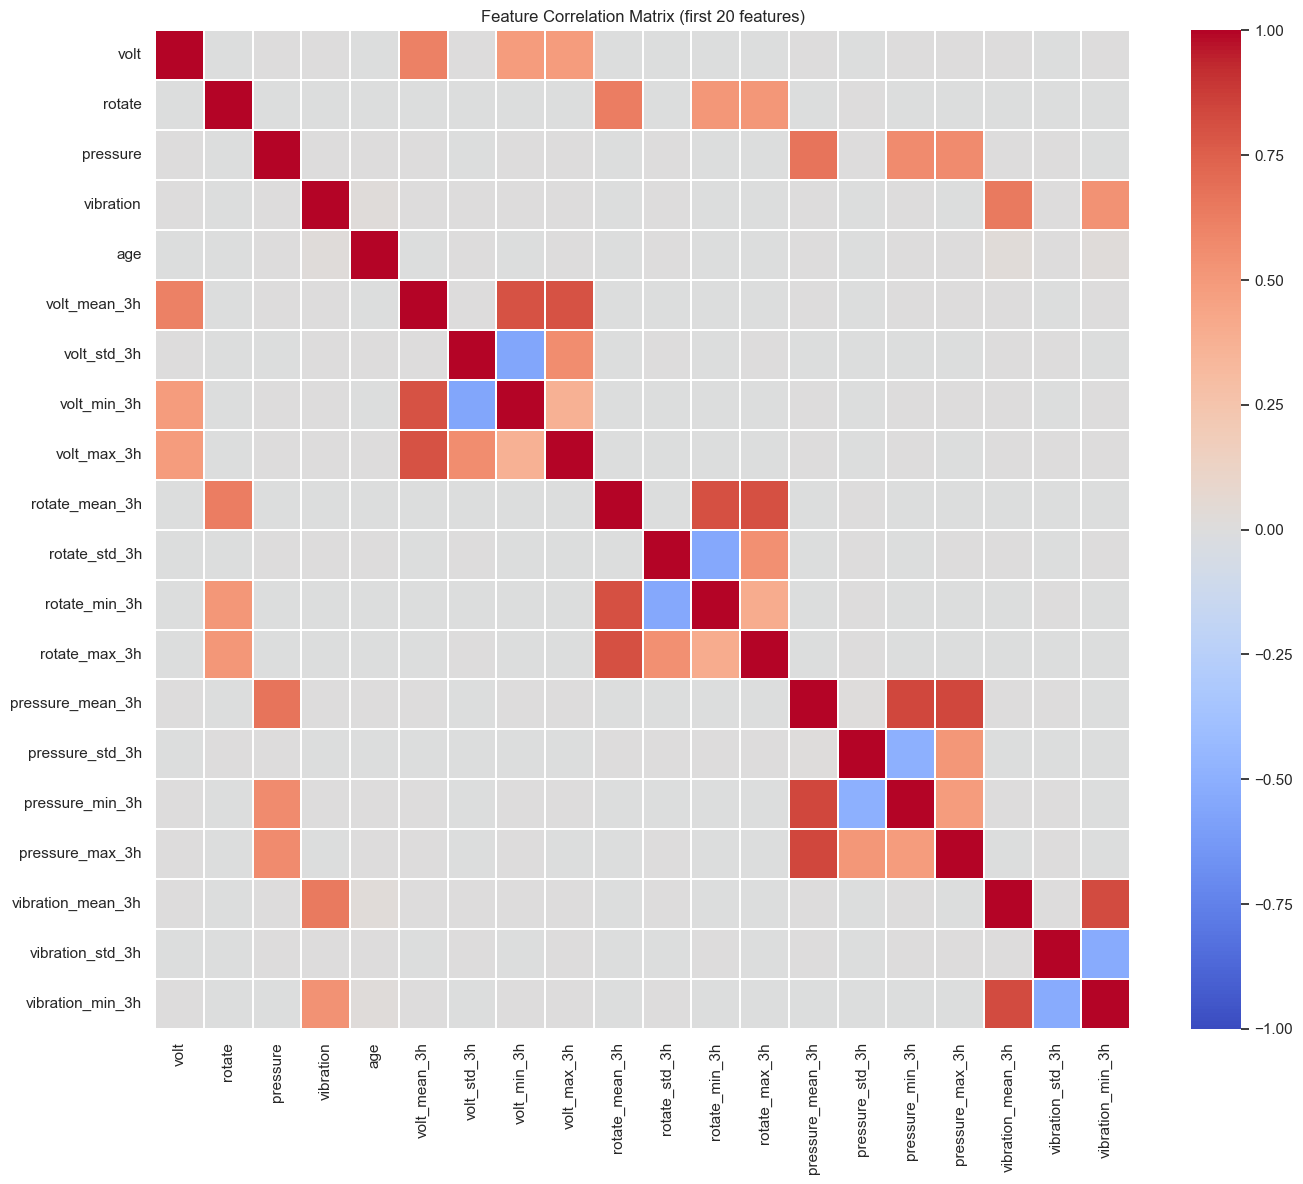

In [5]:
feature_cols = [c for c in feature_df.columns if c not in ["machineID", "datetime", "model"]]
sample_cols = feature_cols[:20]
corr = feature_df[sample_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot=False)
ax.set_title("Feature Correlation Matrix (first 20 features)")
plt.tight_layout()
plt.show()

In [6]:
feature_df

,datetime,machineID,volt,rotate,pressure,vibration,age,volt_mean_3h,volt_std_3h,volt_min_3h,...,error4_count_24h,error5_count_24h,hours_since_comp1,hours_since_comp2,hours_since_comp3,hours_since_comp4,model_model1,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,176.217853,0.000000,176.217853,...,0.0,0.0,456.0,5136.0,3696.0,4056.0,False,False,True,False
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,169.548538,9.431836,162.879223,...,0.0,0.0,457.0,5137.0,3697.0,4057.0,False,False,True,False
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,170.028993,6.721032,162.879223,...,0.0,0.0,458.0,5138.0,3698.0,4058.0,False,False,True,False
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,165.443986,4.807415,162.462833,...,0.0,0.0,459.0,5139.0,3699.0,4059.0,False,False,True,False
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,163.687586,6.773501,157.610021,...,0.0,0.0,460.0,5140.0,3700.0,4060.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876095,2016-01-01 02:00:00,100,179.438162,395.222827,102.290715,50.771941,5,170.306956,8.457322,162.742669,...,0.0,0.0,1988.0,188.0,1988.0,1268.0,False,False,False,True
876096,2016-01-01 03:00:00,100,189.617555,446.207972,98.180607,35.123072,5,177.266129,13.568463,162.742669,...,0.0,0.0,1989.0,189.0,1989.0,1269.0,False,False,False,True
876097,2016-01-01 04:00:00,100,192.483414,447.816524,94.132837,48.314561,5,187.179710,6.855798,179.438162,...,0.0,0.0,1990.0,190.0,1990.0,1270.0,False,False,False,True
876098,2016-01-01 05:00:00,100,165.475310,413.771670,104.081073,44.835259,5,182.525427,14.835200,165.475310,...,0.0,0.0,1991.0,191.0,1991.0,1271.0,False,False,False,True
